# UR3e Model

## 1. Initialization

In [26]:
%pip install ipympl
%matplotlib ipympl
import roboticstoolbox as rtb
import numpy as np

Note: you may need to restart the kernel to use updated packages.


In [27]:
# We will setup the robotic arm using the DH parameters given
# by Universal Robots. Source:
# https://www.universal-robots.com/articles/ur/application-installation/dh-parameters-for-calculations-of-kinematics-and-dynamics/
joint1 = rtb.RevoluteDH(d=0.15185, a=0, alpha=np.pi/2)
joint2 = rtb.RevoluteDH(d=0, a=-0.24355, alpha=0)
joint3 = rtb.RevoluteDH(d=0, a=-0.2132, alpha=0)
joint4 = rtb.RevoluteDH(d=0.13105, a=0, alpha=np.pi/2)
joint5 = rtb.RevoluteDH(d=0.08535, a=0, alpha=-np.pi/2)
joint6 = rtb.RevoluteDH(d=0.0921, a=0, alpha=0)

ur3e_model = rtb.DHRobot([joint1, joint2, joint3, joint4, joint5, joint6], name="UR3e Model")


## 2. Usage

### 2a. Forward Kinematics

(X, Y, Z):  [ 0.08535 -0.22315 -0.3049 ]
(R, P, Y):  [ 0.         -1.57079633  1.57079633]


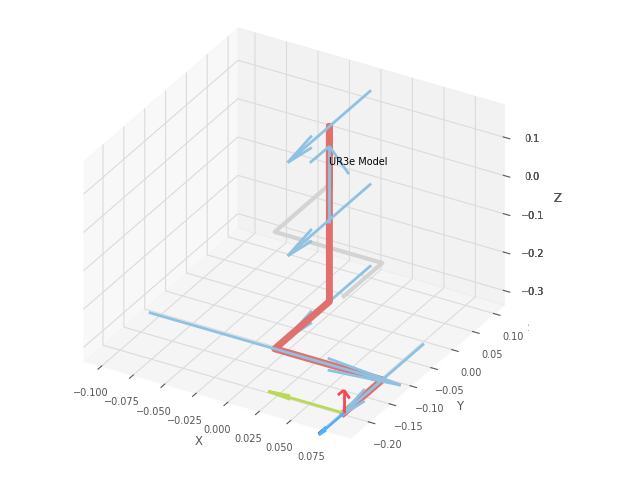

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'UR3e Model')

In [28]:
# Example: Give the target joint positions/rotations 
# in radians and use forward kinematics to find the 
# position of the head.
fk_joint_positions = [
    0,
    np.pi/2,
    0,
    0,
    0,
    0,
]

# The output is a SE(3) of the head/end position.
result = ur3e_model.fkine(fk_joint_positions)

# We can interpret the result as both the X,Y,Z coordinates:
xyz = result.t
print("(X, Y, Z): ", xyz)
# As well as the Roll,Pitch,Yaw (R,P,Y) values:
rpy = result.rpy()
print("(R, P, Y): ", rpy)

# We can also plot the positions in 3D space.
ur3e_model.plot(fk_joint_positions)

### 2b. Trajectories

[[ 0.          0.          0.          0.          0.          0.        ]
 [ 0.         -0.01811567  0.         -0.01811567  0.          0.        ]
 [ 0.         -0.1200263   0.         -0.1200263   0.          0.        ]
 [ 0.         -0.3296733   0.         -0.3296733   0.          0.        ]
 [ 0.         -0.62311526  0.         -0.62311526  0.          0.        ]
 [ 0.         -0.94768106  0.         -0.94768106  0.          0.        ]
 [ 0.         -1.24112302  0.         -1.24112302  0.          0.        ]
 [ 0.         -1.45077003  0.         -1.45077003  0.          0.        ]
 [ 0.         -1.55268066  0.         -1.55268066  0.          0.        ]
 [ 0.         -1.57079633  0.         -1.57079633  0.          0.        ]]


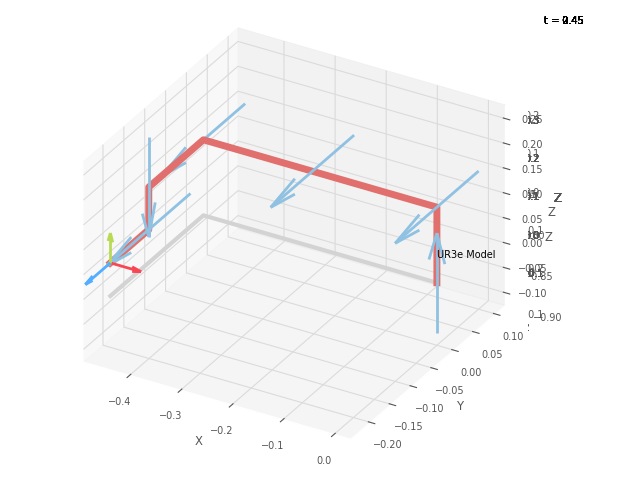

PyPlot3D backend, t = 0.49999999999999994, scene:
  robot: Text(0.0, 0.0, 'UR3e Model')

In [32]:
# Example: Give the initial and target joint 
# positions/rotations in radians, and step
# through the trajectory
start = [
    0,
    0,
    0,
    0,
    0,
    0,
]

end = [0, -np.pi/2, 0, -np.pi/2, 0, 0]


trajectory = rtb.jtraj(start, end, 10)

# The steps of trajectory are given as an array-of-arrays.
steps = trajectory.q
print(steps)

# We can visualize the trajectory steps in 3D space:
ur3e_model.plot(steps)

In [33]:
# show attributes of traj
print("Trajectory q shape:", trajectory.q.shape)
print("First configuration in trajectory:", trajectory.q[0])
print("Last configuration in trajectory:", trajectory.q[-1]) 
print("Time steps (1-5):", trajectory.t[:5])

Trajectory q shape: (10, 6)
First configuration in trajectory: [0. 0. 0. 0. 0. 0.]
Last configuration in trajectory: [ 0.         -1.57079633  0.         -1.57079633  0.          0.        ]
Time steps (1-5): [0.         1.11111111 2.22222222 3.33333333 4.44444444]


In [34]:
# Get end-effector coordinates for final position
final_pose = ur3e_model.fkine(trajectory.q[-1])
xyz = final_pose.t
rpy = final_pose.rpy()
print("Final position (X, Y, Z):", xyz)
print("Final orientation (R, P, Y):", rpy)

Final position (X, Y, Z): [ 1.07615487e-15 -2.23150000e-01  6.93950000e-01]
Final orientation (R, P, Y): [-1.57079633e+00 -3.43024900e-15  3.14159265e+00]
